批量文件夹计算不同细胞类型之间的互相关性
- 四类神经元（CamkII，PV，VIP，SST）的平均累计分布图，直接对每类神经元的多条累计分布曲线求平均，而不是对每类神经元的所有样本重新求累计分布曲线，因为考虑每类神经元的各组是独立的，并且各组的神经元的数量不一样
- 频率分布直方图的取值范围改为-3到3，同时减少bar的数量
- 从append 3 完成测试，先进行t分布单尾检验进行均值为0的假设，说明原数据均为显著性，再进行z分布单尾检验，计算左侧检验并保留95%置信度，对于p值小于0.05的结果进行丢弃

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from typing import Tuple, List, Dict, Optional
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy import stats
import os

In [2]:
def calculate_ccf(
    x: np.ndarray,
    y: np.ndarray,
    normalize: bool = False,
    type: str = 'correlation',
    log_max: int = 30,
    return_plot: bool = True,
    return_intermediate: bool = False
):
    """
    计算 x 与 y 的互相关，返回统计信息和可选绘图，对应 R 的 CalculateCCF 函数
    :param x: 输入序列 x（对应 R 的 x，通常为 area$V1）
    :param y: 输入序列 y（对应 R 的 y，通常为信号列）
    :param normalize: 是否标准化（对应 R 的 normalize=T）
    :param type: 互相关类型（'correlation' 或 'covariance'，对应 R 的 type）
    :param log_max: 最大滞后值（对应 R 的 lag.max=log_max）
    :param return_plot: 是否返回绘图对象
    :param return_intermediate: 是否返回中间互相关结果
    :return: 包含 stats（统计）、plot（绘图，可选）、ccf（中间结果，可选）的字典
    """
    # 1. 标准化处理（对应 R 的 scale(x)）
    if normalize:
        x = (x - np.mean(x)) / np.std(x)  # 标准化为均值0、标准差1
        y = (y - np.mean(y)) / np.std(y)

    # 2. 计算互相关（对应 R 的 ccf 函数）
    # scipy 的 correlate 需手动计算滞后，mode='full' 对应 R 的 ccf 默认范围
    if type == 'correlation':
        # 相关系数（归一化互相关，对应 R 的 type='correlation'）
        corr = sp_signal.correlate(x, y, mode='full', method='fft')
        # 归一化到 [-1, 1]（与 R 的 ccf 结果一致）
        corr = corr / np.sqrt(np.dot(x, x) * np.dot(y, y))
    elif type == 'covariance':
        # 协方差（对应 R 的 type='covariance'）
        corr = sp_signal.correlate(x, y, mode='full', method='fft')
        corr = corr / len(x)  # 与 R 的协方差计算逻辑一致
    else:
        raise ValueError(f"type 必须为 'correlation' 或 'covariance'，当前为 {type}")

    # 计算滞后值（对应 R 的 ccf_result$lag）
    lags = np.arange(-len(x) + 1, len(x))  # 滞后范围：-(n-1) ~ n-1
    # 截断到 log_max（对应 R 的 lag.max=log_max）
    lag_mask = np.abs(lags) <= log_max
    lags = lags[lag_mask]
    corr = corr[lag_mask]

    # 3. 提取统计信息（对应 R 的 stats 计算）
    max_idx = np.argmax(np.abs(corr))  # 最大绝对值对应的索引
    best_lag = lags[max_idx]
    best_R = round(corr[max_idx], 2)  # 保留2位小数（对应 R 的 digits=2）
    # 滞后=0 时的相关系数（对应 R 的 which(ccf_result$lag==0)）
    orig_idx = np.where(lags == 0)[0][0]
    orig_R = round(corr[orig_idx], 2)

    stats = {
        'best_lag': best_lag,
        'best_R': best_R,
        'orig_R': orig_R
    }

    # 4. 时间序列对齐（对应 R 的 lag/lead 函数）
    df = pd.DataFrame({
        't': np.arange(1, len(x) + 1),  # 1-based 时间轴（与 R 一致）
        'x': x,
        'y': y
    })
    if best_lag > 0:
        # y 滞后 best_lag（对应 R 的 lag(y, best_lag)）
        df['y_aligned'] = df['y'].shift(best_lag)
        align_color = 'red'
    else:
        # y 超前 abs(best_lag)（对应 R 的 lead(y, abs(best_lag))）
        df['y_aligned'] = df['y'].shift(-abs(best_lag))
        align_color = 'blue'
    df = df.dropna()  # 对应 R 的 na.omit()

    # 5. 绘图（对应 R 的 ggplot 逻辑）
    output = {'stats': stats}
    if return_plot:
        # 应用风格（对应 R 的 LargeTheme(title.size=10, axis.size=8)）
        # large_theme(axis_size=8, title_size=10, legend_position='none')

        # 创建绘图对象
        fig, ax = plt.subplots(figsize=(8, 4))
        # # 绘制 x（浅灰色实线）
        ax.plot(df['t'], df['x'], color='lightgrey', linewidth=0.5, label='x')
        # 绘制原始 y（黑色虚线）
        ax.plot(df['t'], df['y'], color='black', linewidth=0.5, linestyle='--', label='y')
        # 绘制对齐后 y（红色/蓝色实线）
        ax.plot(df['t'], df['y_aligned'], color=align_color, linewidth=0.5, label='y_aligned')

        # 标题和标签（对应 R 的 ggtitle 和 aes 标签）
        ax.set_title(f'Lag {best_lag}\nR = {best_R} | {orig_R}')
        ax.set_xlabel('t')
        ax.set_ylabel('Value')
        ax.legend().set_visible(True)  # 隐藏图例（对应 R 的 theme(legend.position="none")）

        output['plot'] = fig  # 存储绘图对象
        # plt.close(fig)  # 关闭图形避免重复显示

    # 6. 返回中间结果（对应 R 的 return_intermediate=F）
    if return_intermediate:
        output['ccf'] = {
            'acf': corr,
            'lag': lags,
            'n.used': len(x),
            'type': type,
            'lag.max': log_max
        }

    return output

In [3]:
def cross_correlation(
    cell_cross_correlation: pd.DataFrame,
):
    """
    先进行t分布单尾检验进行均值为0的假设,说明原数据均为显著性,再进行z分布单尾检验,计算左侧检验并保留95%置信度,对于p值小于0.05的结果进行丢弃
    """
    # 首先剔除cell_cross_correlation['best_R']中小于0的值（小于0相当于负相关）
    cell_cross_correlation_df = cell_cross_correlation.copy()

    # 按照best_R降序排序
    sorted_df_total = cell_cross_correlation_df.sort_values(by='best_R', ascending=False).copy()

    # 计算z分布的单尾检验（右侧检验，保留较大值）
    # 首先获取best_R列的值
    r_values_total = sorted_df_total['best_R'].values

    # 计算样本量、均值和标准差
    n = len(r_values_total)

    # 对于z分布单尾检验，我们需要假设总体均值为0（无相关）
    # 计算每个r值的z分数
    # 使用Fisher变换将相关系数转换为近似正态分布
    # 注意：当r接近±1时，Fisher变换的效果更好
    z_scores_total= np.arctanh(r_values_total)  # Fisher z变换

    # 计算z统计量（右侧检验）
    # 对于总体相关系数ρ=0的检验，标准误为1/sqrt(n-3)
    standard_error = 1 / np.sqrt(n - 3)
    z_stats_total = z_scores_total / standard_error

    # 计算单尾p值（右侧检验，保留较大的r值）
    p_values_total = stats.norm.sf(z_stats_total)

    # 将z分数和p值添加到DataFrame中
    sorted_df_total['z_score'] = z_scores_total
    sorted_df_total['z_stat'] = z_stats_total
    sorted_df_total['p_value'] = p_values_total

    # 保留95%置信度的结果（p值 < 0.05）
    group_significant_total = sorted_df_total[p_values_total < 0.05].copy()

    # 输出结果统计
    print(f"原始数据点数: {len(sorted_df_total)}")
    print(f"统计显著的数据点数 (p < 0.05): {len(group_significant_total)}")

    # 如果需要，也可以按p值排序显示前几个结果
    if not group_significant_total.empty:
        print("\n统计显著结果的前5个（按p值排序）:")
        print(group_significant_total.sort_values('p_value').head())
    else:
        print("没有统计显著的结果")

    # 获取group_significant_total中的所有unit_ID
    unit_ids_to_serve = group_significant_total['unit_ID'].unique()

    # 从cell_cross_correlation中过滤掉这些unit_ID对应的行
    positive_only_df = cell_cross_correlation_df[cell_cross_correlation_df['unit_ID'].isin(unit_ids_to_serve)]    

    # 按照best_R降序排序
    sorted_df = positive_only_df.sort_values(by='best_R', ascending=False).copy()

    # 计算z分布的单尾检验（右侧检验，保留较大值）
    # 首先获取best_R列的值
    r_values = sorted_df['best_R'].values

    # 计算样本的均值标准差和zscore值
    mean_r = np.mean(r_values)
    std_r = np.std(r_values, ddof=0)
    z_scores = (r_values - mean_r) / std_r

    # 直接将z_scores作为z统计量用于检验
    z_stat = z_scores

    # 计算单尾p值（左侧检验）
    p_values = stats.norm.cdf(z_stat)

    # 将z分数和p值添加到DataFrame中
    sorted_df['z_score'] = z_scores
    sorted_df['z_stat'] = z_stat
    sorted_df['p_value'] = p_values

    # 保留95%置信度的结果（p值 < 0.025）
    group_significant = sorted_df[p_values < 0.05].copy()

    # 输出结果统计
    print(f"原始数据点数: {len(sorted_df)}")
    print(f"统计显著的数据点数 (p < 0.05): {len(group_significant)}")

    # 如果需要，也可以按p值排序显示前几个结果
    if not group_significant.empty:
        print("\n统计显著结果的前5个（按p值排序）:")
        print(group_significant.sort_values('p_value').head())
    else:
        print("没有统计显著的结果")

    # 获取group_significant中的所有unit_ID
    unit_ids_to_remove = group_significant['unit_ID'].unique()

    # 从positive_only_df中过滤掉这些unit_ID对应的行
    filtered_cross_correlation = positive_only_df[~positive_only_df['unit_ID'].isin(unit_ids_to_remove)]

    return filtered_cross_correlation,group_significant,group_significant_total

C:\Users\Admin\AppData\Local\Temp\ipykernel_28952\3974451142.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)


原始数据点数: 10
统计显著的数据点数 (p < 0.05): 9

统计显著结果的前5个（按p值排序）:
    unit_ID  best_lag  best_R  orig_R   z_score    z_stat   p_value
4       4.0      -7.0    0.90    0.86  1.472219  3.895127  0.000049
1       1.0      -8.0    0.89    0.86  1.421926  3.762062  0.000084
14     14.0      -9.0    0.87    0.84  1.333080  3.526997  0.000210
7       7.0      -7.0    0.86    0.83  1.293345  3.421868  0.000311
10     10.0      -7.0    0.81    0.78  1.127029  2.981839  0.001433
原始数据点数: 9
统计显著的数据点数 (p < 0.05): 0
没有统计显著的结果


C:\Users\Admin\AppData\Local\Temp\ipykernel_28952\3974451142.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)


原始数据点数: 6
统计显著的数据点数 (p < 0.05): 2

统计显著结果的前5个（按p值排序）:
    unit_ID  best_lag  best_R  orig_R   z_score    z_stat   p_value
9       9.0     -16.0    0.83    0.77  1.188136  2.057913  0.019799
11     11.0      -8.0    0.79    0.75  1.071432  1.855774  0.031743
原始数据点数: 2
统计显著的数据点数 (p < 0.05): 0
没有统计显著的结果


C:\Users\Admin\AppData\Local\Temp\ipykernel_28952\3974451142.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)


...

C:\Users\Admin\AppData\Local\Temp\ipykernel_28952\3974451142.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)


原始数据点数: 105
统计显著的数据点数 (p < 0.05): 105

统计显著结果的前5个（按p值排序）:
     unit_ID  best_lag  best_R  orig_R   z_score    z_stat       p_value
119    119.0     -17.0    0.64    0.57  0.758174  7.657179  9.503047e-15
88      88.0      -3.0    0.62    0.62  0.725005  7.322192  1.219760e-13
36      36.0      -7.0    0.61    0.60  0.708921  7.159755  4.041075e-13
56      56.0     -20.0    0.61    0.58  0.708921  7.159755  4.041075e-13
52      52.0     -29.0    0.60    0.56  0.693147  7.000443  1.275769e-12
原始数据点数: 105
统计显著的数据点数 (p < 0.05): 5

统计显著结果的前5个（按p值排序）:
     unit_ID  best_lag  best_R  orig_R   z_score    z_stat   p_value
15      15.0     -21.0    0.28    0.27 -3.551497 -3.551497  0.000192
106    106.0       9.0    0.29    0.28 -3.394616 -3.394616  0.000344
62      62.0      -5.0    0.34    0.33 -2.610209 -2.610209  0.004524
16      16.0      25.0    0.38    0.36 -1.982683 -1.982683  0.023701
131    131.0     -13.0    0.40    0.37 -1.668920 -1.668920  0.047567


C:\Users\Admin\AppData\Local\Temp\ipykernel_28952\3974451142.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)


原始数据点数: 83
统计显著的数据点数 (p < 0.05): 83

统计显著结果的前5个（按p值排序）:
     unit_ID  best_lag  best_R  orig_R   z_score     z_stat       p_value
4        4.0     -24.0    0.87    0.82  1.333080  11.923427  4.467809e-33
76      76.0     -17.0    0.84    0.83  1.221174  10.922508  4.498818e-28
137    137.0     -27.0    0.83    0.80  1.188136  10.627015  1.115701e-26
123    123.0     -26.0    0.80    0.74  1.098612   9.826287  4.337932e-23
144    144.0     -13.0    0.79    0.78  1.071432   9.583176  4.705270e-22
原始数据点数: 83
统计显著的数据点数 (p < 0.05): 4

统计显著结果的前5个（按p值排序）:
     unit_ID  best_lag  best_R  orig_R   z_score    z_stat   p_value
129    129.0      22.0    0.27    0.26 -2.003883 -2.003883  0.022541
96      96.0      25.0    0.27    0.24 -2.003883 -2.003883  0.022541
103    103.0       3.0    0.29    0.28 -1.857149 -1.857149  0.031645
78      78.0       5.0    0.29    0.29 -1.857149 -1.857149  0.031645


C:\Users\Admin\AppData\Local\Temp\ipykernel_28952\3974451142.py:169: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_reset = result.groupby('column').apply(lambda x: x.reset_index(drop=True))


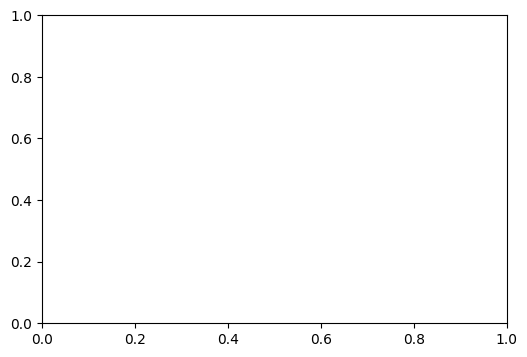

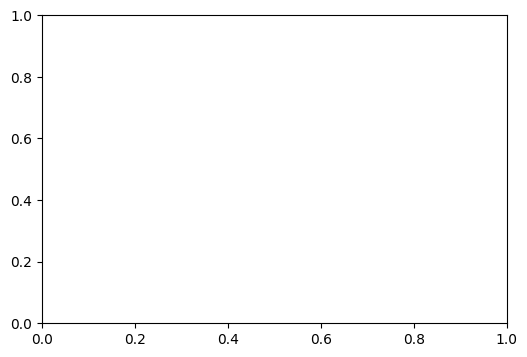

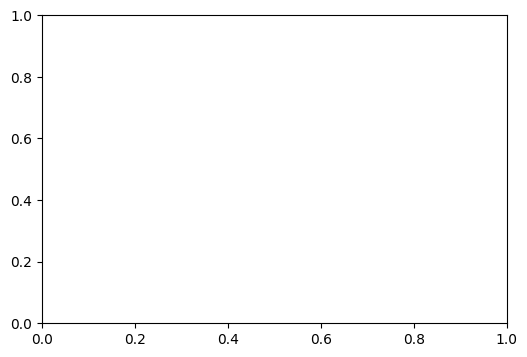

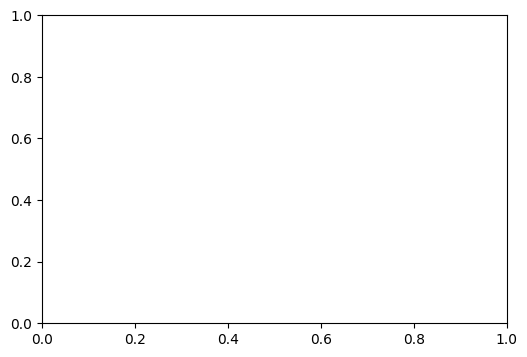

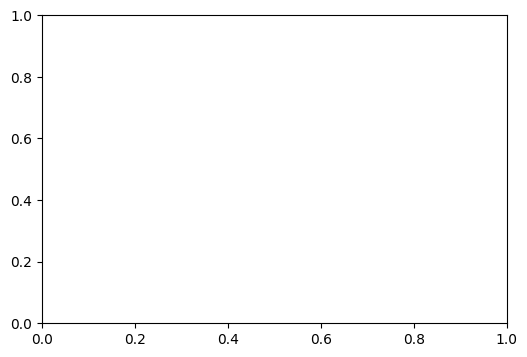

In [4]:
path = r'E:\rq\M2\signal_behavior'
type_list = ['SST','PV','VIP','Hsyn','CamkII']
file_result = r'D:\RQ\M2 Project\summary\batch one cross correlation 5'

for type_ in type_list:
    type_path = os.path.join(path,type_)
    file_list = os.listdir(type_path)
    # 每个类型的累计频率分布曲线
    cell_cross_correlation_type = pd.DataFrame()
    # 设置颜色 palette 用于区分10列数据
    colors = sns.color_palette("tab10", n_colors=len(type_list))
    
    for file_ in file_list:
        file_path = os.path.join(type_path,file_)

        save_path = os.path.join(file_result,type_,file_)
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        fig_path = os.path.join(save_path,'neuron behavior cross correlation figures')
        if not os.path.exists(fig_path):
            os.makedirs(fig_path)

        # 读取实际数据
        df_signal = pd.read_csv(file_path+'//C.csv')
        df_raw = pd.read_csv(file_path+'//YrA.csv')
        df_behavior = pd.read_csv(file_path+'//Area_Change.csv')

        df_drop_id = None

        # 确保列名统一
        df_signal = df_signal.rename(columns={"unit_id":"unit_id","frame":"t","C":"value"})
        df_raw = df_raw.rename(columns={"unit_id":"unit_id","frame":"t","YrA":"value"})

        # Step 2: 以 C 为主，获取有效 ID
        if df_drop_id is not None:
            valid_ids = set(df_signal['unit_id'].unique()) - set(df_drop_id[0].values.tolist())
        else:
            valid_ids = set(df_signal['unit_id'].unique())

        # Step 3: 筛选 YrA 和 C 中的有效 ID
        df_raw = df_raw[df_raw['unit_id'].isin(valid_ids)].copy()
        df_signal = df_signal[df_signal['unit_id'].isin(valid_ids)].copy()

        # Step 4: 对数据进行下采样，每3帧取平均
        def downsample_data(df):
            # 确保按unit_id和t排序
            df_sorted = df.sort_values(['unit_id', 't']).copy()
                # 创建分组键，每2帧一组
            df_sorted['group'] = df_sorted.groupby('unit_id')['t'].transform(lambda x: (x - x.min()) // 2)
                # 按unit_id和group分组，计算value的平均值，t取每组的第一个值
            df_downsampled = df_sorted.groupby(['unit_id', 'group']).agg({'t': 'first', 'value': 'mean'}).reset_index(level='unit_id').reset_index(drop=True)
            return df_downsampled

        # 应用下采样函数
        df_raw = downsample_data(df_raw)
        df_signal = downsample_data(df_signal)

        # 5. 标准化 C：按 id 分组
        df = pd.merge(df_raw, df_signal, on=['unit_id', 't'], suffixes=('_YrA', '_C'))

        df['residual'] = df['value_YrA'] - df['value_C']
        df['value_z'] = df['value_C'] / df.groupby('unit_id')['residual'].transform('std')

        # 将行为和信号的数据按照最短的帧数进行截断
        df_behavior = df_behavior.T.reset_index(drop=True)
        min_len=min(df.groupby('unit_id').size().min(),len(df_behavior))

        # df_signal=df_signal.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)
        df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)
        resized_df_signal_dic_update = df_signal.pivot(index='t', columns='unit_id', values='value_z')  # 行=时间，列=id
        df_behavior_update = df_behavior[:min_len]

        # 对TST和OFT的每一列进行z-score标准化
        resized_df_signal_dic_update = resized_df_signal_dic_update.apply(zscore, axis=0)

        # 创建 MinMaxScaler 对象
        minmax_scaler = MinMaxScaler()

        # 对 DataFrame 进行 Min-Max 归一化
        minmax_signal = minmax_scaler.fit_transform(resized_df_signal_dic_update)
        minmax_behavior = minmax_scaler.fit_transform(df_behavior_update)

        # 将结果转换回 DataFrame
        minmax_df_signal = pd.DataFrame(minmax_signal, columns=resized_df_signal_dic_update.columns)
        minmax_df_behavior = pd.DataFrame(minmax_behavior, columns=df_behavior_update.columns)

        # 计算minmax_df_signal的每一列细胞信号和minmax_df_behavior[0]之间的互相关性，保存每个细胞和行为之间的互相关性的图，并将所有细胞和行为之间互相关性的数据保存到一张表格中
        cell_cross_correlation = pd.DataFrame(columns=['unit_ID','best_lag','best_R','orig_R'])
        tag = 0
        for cell in list(minmax_df_signal.columns):
            output = calculate_ccf(minmax_df_behavior[0],minmax_df_signal[cell])
            output['plot'].savefig(fig_path + "//" + str(cell) + ".pdf",
                                dpi=300,
                                bbox_inches='tight')
            plt.close()
            cell_cross_correlation.loc[tag] = [cell,output['stats']['best_lag'],output['stats']['best_R'],output['stats']['orig_R']]
            tag = tag + 1

        # 从cell_cross_correlation的'best_lag'中去除边界值（绝对值=30）
        cell_cross_correlation = cell_cross_correlation.copy()
        cell_cross_correlation = cell_cross_correlation[abs(cell_cross_correlation['best_lag'])<30]
        cell_cross_correlation.to_csv(save_path + "//" + 'original_cell_cross_correlation.csv',index=False)
        cell_cross_correlation,group_significant,group_significant_total = cross_correlation(cell_cross_correlation)
        cell_cross_correlation.to_csv(save_path + "//" + 'cell_cross_correlation.csv',index=False)
        group_significant.to_csv(save_path + "//" + 'group_significant_drop.csv',index=False)
        group_significant_total.to_csv(save_path + "//" + 'group_significant_total_served.csv',index=False)


        # 将表格中的best_log数据，使用频率分布直方图绘制并保存
        fig, ax = plt.subplots(figsize=(6, 4))
        plt.hist(cell_cross_correlation['best_lag'],bins=12,color='skyblue',edgecolor='black',linewidth=1.0,alpha=0.7,density=True)
        plt.title('Distribution of best_lag')
        plt.xlabel('time lag')
        plt.ylabel('frequency')
        # 将x轴刻度标签除以10
        ticks = plt.xticks()[0]
        plt.xticks(ticks, [tick / 10 for tick in ticks])
        plt.savefig(save_path + "//" + 'best_lag_histogram.pdf',
                    dpi=300,
                    bbox_inches='tight')
        plt.close()

        cell_cross_correlation_type = pd.concat([cell_cross_correlation_type,pd.DataFrame(cell_cross_correlation['best_lag']).rename(columns={'best_lag':file_})],axis=1)

    
    fig, ax = plt.subplots(figsize=(6, 4))
    all_cumulative_data = []
    # 循环绘制每列数据的累计分布曲线
    for i, col in enumerate(cell_cross_correlation_type.columns):
        # 处理缺失值并绘制曲线
        data = cell_cross_correlation_type[col]

        sns.kdeplot(data, cumulative=True,color='skyblue',linewidth=2)

        data = data.dropna()
        # 计算核密度估计
        kde = gaussian_kde(data)

        # 生成x轴数据（覆盖数据范围）
        x_min, x_max = -80, 80
        x_values = np.linspace(x_min, x_max, 1000)  # 1000个均匀分布的点
        
        # 计算累计分布（积分）
        y_values = np.array([kde.integrate_box_1d(-np.inf, x) for x in x_values])

        # 存储结果
        df = pd.DataFrame({'best_lag': x_values, 'cumulative_frequency': y_values, 'column': col})
        all_cumulative_data.append(df)
    #合并所有列数据
    result = pd.concat(all_cumulative_data, ignore_index=True)

    # 固定坐标轴范围
    plt.xlim(-60, 60)
    plt.ylim(0, 1)  # 累计频率范围在0-1之间

    plt.xlabel('time lag')
    plt.ylabel('cumulative frequency')
    plt.title('Cumulative Frequency Distribution (Curve Fitting)')
    # 拟合曲线
    ticks = plt.xticks()[0]
    plt.xticks(ticks, [tick / 10 for tick in ticks])
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # 图例放在图外避免遮挡
    plt.tight_layout()
    plt.savefig(os.path.join(file_result,type_, 'best_lag_cumulative_curve.pdf'), dpi=300, bbox_inches='tight')
    plt.close()

    fig, ax = plt.subplots(figsize=(6, 4))
    # 按column分组并重置每组的index
    grouped_reset = result.groupby('column').apply(lambda x: x.reset_index(drop=True))
    # 将累计频率数据转换为宽格式（每行对应相同index的不同组数据）
    cumulative_wide = grouped_reset['cumulative_frequency'].unstack(level=0)
    # 将best_lag数据转换为宽格式
    best_lag_wide = grouped_reset['best_lag'].unstack(level=0)
    # 计算每行（相同index位置）的平均值
    cumulative_wide['average_cumulative'] = cumulative_wide.mean(axis=1)

    # 绘制平均累积频率曲线
    plt.figure(figsize=(10, 6))
    plt.plot(best_lag_wide['1'], cumulative_wide['average_cumulative'], 'b-', linewidth=2)
    plt.xlabel('time lag')
    plt.ylabel('Average Cumulative Frequency')
    plt.title('Groups Average Cumulative Frequency Curve')
    # 将x轴刻度标签除以10
    ticks = plt.xticks()[0]
    plt.xticks(ticks, [tick / 10 for tick in ticks])
    plt.savefig(os.path.join(file_result,type_,'average_cumulative_curve.pdf'), dpi=300, bbox_inches='tight')
    plt.close()

In [5]:
# # 按column分组并重置每组的index
# grouped_reset = result.groupby('column').apply(lambda x: x.reset_index(drop=True))
# # 将累计频率数据转换为宽格式（每行对应相同index的不同组数据）
# cumulative_wide = grouped_reset['cumulative_frequency'].unstack(level=0)
# # 将best_lag数据转换为宽格式
# best_lag_wide = grouped_reset['best_lag'].unstack(level=0)
# # 计算每行（相同index位置）的平均值
# cumulative_wide['average_cumulative'] = cumulative_wide.mean(axis=1)

# # 绘制平均累积频率曲线
# plt.figure(figsize=(10, 6))
# plt.plot(best_lag_wide['1'], cumulative_wide['average_cumulative'], 'b-', linewidth=2)
# plt.xlabel('time lag')
# plt.ylabel('Average Cumulative Frequency')
# plt.title('Groups Average Cumulative Frequency Curve')
# # 将x轴刻度标签除以10
# ticks = plt.xticks()[0]
# plt.xticks(ticks, [tick / 10 for tick in ticks])
# plt.savefig(os.path.join(file_result,type_,'average_cumulative_curve.png'), dpi=300, bbox_inches='tight')
# plt.show()